# Fine-tuning T5 Model with JSON Data (Final Version)

This notebook is optimized for fine-tuning T5 on large datasets (e.g., 54k+ examples) using your custom JSON format.

**Step 1: Install Required Libraries**

In [3]:
!pip install transformers datasets accelerate evaluate sentencepiece

**Step 2: Import Libraries**

In [4]:
import os
import json
from datasets import Dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration, TrainingArguments, Trainer

In [5]:
import os
import json
import torch
import numpy as np
import evaluate

from datasets import Dataset
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

**Step 3: Load Data**

Update `DATA_FILE_PATH` to your JSON file path.

In [6]:
DATA_FILE_PATH = '/kaggle/input/datasets/jehad24/response-generator/training_data_with_responses (1).json'

def load_json_data(file_path):
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Creating a sample for demonstration.")
        sample_data = {
            "TRAINING_DATA": [
                ["Do you remember my previous order?", "memory_check", "Yes! I remember."],
                ["بعد إذنك، سلام يا فرح", "goodbye", "مع السلامة!"]
            ]
        }
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(sample_data, f, ensure_ascii=False, indent=2)
            
    with open(file_path, 'r', encoding='utf-8') as f:
        full_data = json.load(f)
            
    processed_data = []
    for item in full_data['TRAINING_DATA']:
        processed_data.append({'input_text': item[0], 'target_text': item[2]})
            
    return Dataset.from_list(processed_data)

full_dataset = load_json_data(DATA_FILE_PATH)
print(f"Loaded {len(full_dataset)} examples.")


Loaded 54000 examples.


# CELL 5 — Train/Test Split

In [7]:
split_dataset = full_dataset.train_test_split(
    test_size=0.1,
    seed=42
)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Train size: {len(train_dataset)}")
print(f"Eval size: {len(eval_dataset)}")

Train size: 48600
Eval size: 5400


**Step 4: Tokenization**

In [8]:
model_name = "google/mt5-small"
tokenizer = T5Tokenizer.from_pretrained(model_name, legacy=False)

def preprocess_function(examples):

    model_inputs = tokenizer(
        examples["input_text"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        text_target=examples["target_text"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_eval = eval_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/48600 [00:00<?, ? examples/s]

Map:   0%|          | 0/5400 [00:00<?, ? examples/s]

**Step 5: Training**

In [9]:

from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback
import evaluate
import numpy as np
from transformers import MT5ForConditionalGeneration

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    predictions = np.clip(predictions, 0, tokenizer.vocab_size - 1)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    return {"rouge1": result["rouge1"], "rouge2": result["rouge2"], "rougeL": result["rougeL"]}
    

model = MT5ForConditionalGeneration.from_pretrained(model_name)
model.to("cuda" if torch.cuda.is_available() else "cpu")

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,  
    per_device_eval_batch_size=4,   
    gradient_accumulation_steps=4,  
    logging_steps=50,
    save_strategy="epoch",
    eval_strategy="epoch",
    predict_with_generate=True,
    report_to="none",
    fp16=True,
    gradient_checkpointing=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    load_best_model_at_end=True,
    save_total_limit=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Starting training...")
trainer.train()
print("Training finished.")


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,9.074465,0.900180,0.012694,0.000088,0.012207
2,2.628200,0.172351,0.126854,0.063638,0.117136
3,2.017368,0.119842,0.147223,0.083175,0.138140


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished.


**Step 6: Save and Test**

In [10]:
OUTPUT_DIR = "/kaggle/working/MT5-assistify-finetuned"

trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/MT5-assistify-finetuned


In [11]:
def generate_response(text):

    model.eval()

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=128,
            num_beams=5,
            early_stopping=True,
            no_repeat_ngram_size=2
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

sample_input = "بعد إذنك، سلام "

print("User:", sample_input)
print("Bot:", generate_response(sample_input))

User: بعد إذنك، سلام 
Bot: تقدر ترجع المنتج خلال 14 يوم من الاستلام. قولي المنتج واللي بتواجهه بالتحديد.


In [12]:
sample_input = "hello "

print("User:", sample_input)
print("Bot:", generate_response(sample_input))

User: hello 
Bot: Hello! I'm Assistify AI, your medical store assistant. How can I help you today?


## Evaluation

In [13]:

import time, math, re
import numpy as np
import torch
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import defaultdict

def generate_response(text, max_new_tokens=128):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(model.device)
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2,
        )
    latency = time.time() - t0
    return tokenizer.decode(outputs[0], skip_special_tokens=True), latency

# ── 11-A: Perplexity ──────────────────────────────────────
print("=" * 60)
print("  11-A  |  Perplexity on Eval Set")
print("=" * 60)

model.eval()
total_loss, total_tokens = 0.0, 0

for ex in eval_dataset.select(range(min(50, len(eval_dataset)))):
    enc = tokenizer(ex["input_text"], return_tensors="pt",
                    truncation=True, max_length=128).to(model.device)
    lbl = tokenizer(ex["target_text"], return_tensors="pt",
                    truncation=True, max_length=128).to(model.device)["input_ids"]
    with torch.no_grad():
        out = model(**enc, labels=lbl)
    n_toks = lbl.ne(tokenizer.pad_token_id).sum().item()
    total_loss   += out.loss.item() * n_toks
    total_tokens += n_toks

avg_loss   = total_loss / total_tokens
perplexity = math.exp(avg_loss)
print(f"  Avg cross-entropy loss : {avg_loss:.4f}")
print(f"  Perplexity             : {perplexity:.2f}")
print()

# ── 11-B: ROUGE & BLEU ───────────────────────────────────
print("=" * 60)
print("  11-B  |  ROUGE-L & BLEU")
print("=" * 60)

scorer_r = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
sf       = SmoothingFunction().method1
r1s, r2s, rLs, bleus, lats = [], [], [], [], []
sample   = eval_dataset.select(range(min(40, len(eval_dataset))))

for ex in sample:
    pred_text, lat = generate_response(ex["input_text"])
    ref_text = ex["target_text"]
    lats.append(lat)
    scores = scorer_r.score(ref_text, pred_text)
    r1s.append(scores["rouge1"].fmeasure)
    r2s.append(scores["rouge2"].fmeasure)
    rLs.append(scores["rougeL"].fmeasure)
    bleu_s = sentence_bleu([ref_text.split()], pred_text.split(), smoothing_function=sf)
    bleus.append(bleu_s)

print(f"  ROUGE-1  : {np.mean(r1s):.4f}")
print(f"  ROUGE-2  : {np.mean(r2s):.4f}")
print(f"  ROUGE-L  : {np.mean(rLs):.4f}")
print(f"  BLEU     : {np.mean(bleus):.4f}")
print(f"  Avg latency : {np.mean(lats)*1000:.0f} ms/sample")
print()

# ── 11-C: Language Detection ─────────────────────────────
print("=" * 60)
print("  11-D  |  Language Detection Accuracy")
print("=" * 60)

def is_arabic(text):
    return bool(re.search(r'[\u0600-\u06FF]', text))

lang_tests = [
    ("اطلبلي weight scale دلوقتي",           True),
    ("How can I return my blood pressure monitor?", False),
    ("عايز أعرف سعر جهاز الأكسجين",         True),
    ("What is the price of a pulse oximeter?",     False),
    ("ممكن تساعدني في الطلب؟",               True),
    ("Do you deliver to Cairo?",               False),
]

correct = 0
for text, expect_ar in lang_tests:
    pred, _ = generate_response(text)
    got_ar  = is_arabic(pred)
    ok      = (got_ar == expect_ar)
    correct += ok
    print(f"  {'✓' if ok else '✗'}  [{'Arabic' if expect_ar else 'English'}] → [{'Arabic' if got_ar else 'English'}]")
    print(f"     Input   : {text[:60]}")
    print(f"     Response: {pred[:80]}")

acc = correct / len(lang_tests) * 100
print(f"\n  Language accuracy: {correct}/{len(lang_tests)} = {acc:.1f}%")

# ── Summary ──────────────────────────────────────────────
print()
print("╔" + "═"*58 + "╗")
print("║" + " T5 EVALUATION SUMMARY ".center(58) + "║")
print("╠" + "═"*58 + "╣")
print(f"║  Perplexity         : {perplexity:>8.2f}" + " "*22 + "║")
print(f"║  ROUGE-L            : {np.mean(rLs):>8.4f}" + " "*22 + "║")
print(f"║  BLEU               : {np.mean(bleus):>8.4f}" + " "*22 + "║")
print(f"║  Lang accuracy      : {acc:>7.1f}%" + " "*22 + "║")
print(f"║  Avg latency        : {np.mean(lats)*1000:>6.0f} ms" + " "*21 + "║")
print("╚" + "═"*58 + "╝")


  11-A  |  Perplexity on Eval Set
  Avg cross-entropy loss : 0.6222
  Perplexity             : 1.86

  11-B  |  ROUGE-L & BLEU
  ROUGE-1  : 0.2154
  ROUGE-2  : 0.1327
  ROUGE-L  : 0.2000
  BLEU     : 0.0538
  Avg latency : 475 ms/sample

  11-D  |  Language Detection Accuracy
  ✓  [Arabic] → [Arabic]
     Input   : اطلبلي weight scale دلوقتي
     Response: تقدر ترجع المنتج خلال 14 يوم من الاستلام. قولي المنتج واللي بتواجهه بالتحديد.
  ✓  [English] → [English]
     Input   : How can I return my blood pressure monitor?
     Response: I'll return products within 14 days of delivery. Could you share more details so
  ✓  [Arabic] → [Arabic]
     Input   : عايز أعرف سعر جهاز الأكسجين
     Response: بخصوص الأكسجين عشان أبدأ الإجراء. إيه الطريقة اللي بتفكر فيها؟
  ✓  [English] → [English]
     Input   : What is the price of a pulse oximeter?
     Response: I'll get you the details! Which product are you asking about?
  ✓  [Arabic] → [Arabic]
     Input   : ممكن تساعدني في الطلب؟
     Response:

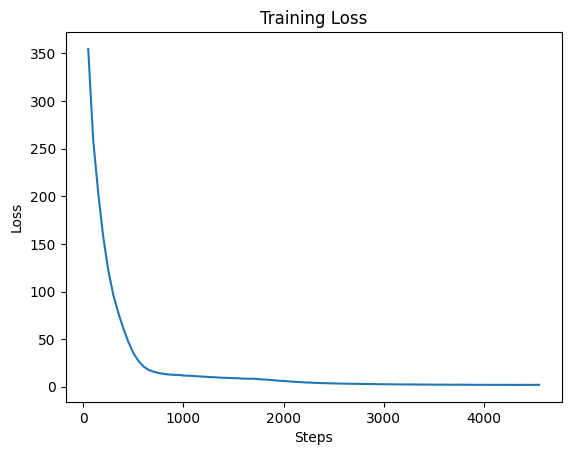

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history

df = pd.DataFrame([x for x in logs if "loss" in x])

plt.plot(df["step"], df["loss"])
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()